# Model 06: Logistic Regression (Classification Baseline)

### Objective
We are shifting from predicting exact percentages to predicting the Contextual Bands (High, Medium, Low) that we engineered in Notebook 00. Logistic Regression establishes the mathematical baseline for these probabilities.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('evidence', exist_ok=True)

### 1. Load Datasets & Encode Targets
We load the classification targets and convert the text ('Low', 'Medium', 'High') into numbers (0, 1, 2) for the algorithms.

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
X_train = X_train.fillna(X_train.mean())

y_train_raw = pd.read_csv('../../../../../data/processed/y_train_class.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val_raw = pd.read_csv('../../../../../data/processed/y_val_class.csv').squeeze()

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_val = le.transform(y_val_raw)

print("Classes:", le.classes_)
print("Datasets loaded successfully.")

Classes: ['High' 'Low' 'Medium']
Datasets loaded successfully.


### 2. Model Training

In [3]:
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print("✅ Logistic Regression Trained Successfully.")

✅ Logistic Regression Trained Successfully.


### 3. Classification Evaluation

In [4]:
def evaluate_classification(model, X, y_true, model_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    try:
        y_prob = model.predict_proba(X)
        roc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    except AttributeError:
        roc = np.nan
        
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if not np.isnan(roc):
        print(f"ROC-AUC:  {roc:.4f}\n")
    else:
        print("ROC-AUC:  N/A\n")
        
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_pred, acc, f1, roc

print("========== TRAINING SET ==========")
_, train_acc, train_f1, train_roc = evaluate_classification(log_reg, X_train, y_train, "06_logistic_regression (TRAIN)")

print("========== VALIDATION SET ==========")
val_preds, val_acc, val_f1, val_roc = evaluate_classification(log_reg, X_val, y_val, "06_logistic_regression (VAL)")

========== TRAINING SET ==========
--- 06_logistic_regression (TRAIN) ---
Accuracy: 0.5200
F1 Score: 0.5215
ROC-AUC:  0.7018

              precision    recall  f1-score   support

        High       0.55      0.59      0.57       105
         Low       0.50      0.51      0.51       124
      Medium       0.50      0.47      0.49       121

    accuracy                           0.52       350
   macro avg       0.52      0.52      0.52       350
weighted avg       0.52      0.52      0.52       350

========== VALIDATION SET ==========
--- 06_logistic_regression (VAL) ---
Accuracy: 0.3600
F1 Score: 0.3666
ROC-AUC:  0.5381

              precision    recall  f1-score   support

        High       0.25      0.69      0.37        16
         Low       0.70      0.29      0.41        24
      Medium       0.43      0.26      0.32        35

    accuracy                           0.36        75
   macro avg       0.46      0.41      0.37        75
weighted avg       0.48      0.36      0.

### 4. Confusion Matrix
Visualizing exactly where the model gets confused (e.g., predicting High when it was actually Low).

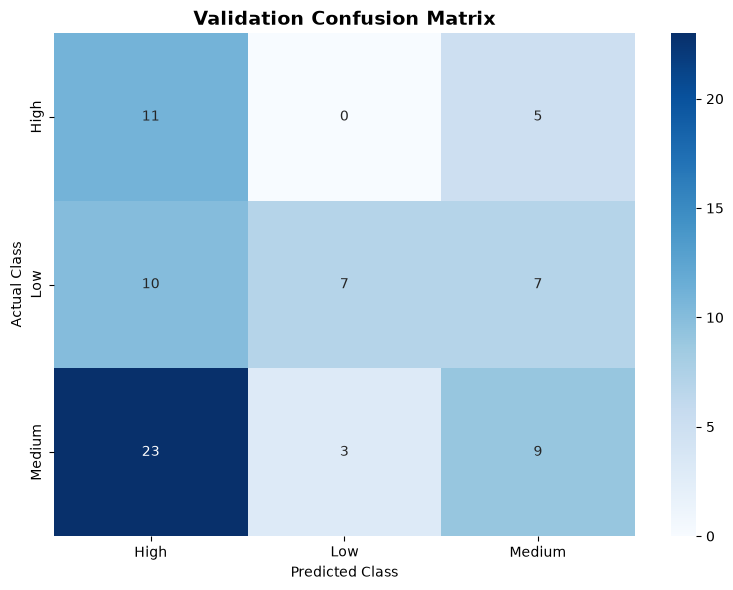

In [5]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('evidence/01_logreg_confusion_matrix.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [6]:
import datetime
import os

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['06_logistic_regression'],
    'Model_Type': ['Classification'],
    'Val_MAE': [np.nan],
    'Val_RMSE': [np.nan],
    'Val_MAPE': [np.nan],
    'Val_R2': [np.nan],
    'Val_Accuracy': [val_acc],
    'Val_F1': [val_f1],
    'Val_ROCAUC': [val_roc]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
